# Intro

In this notebook we're going to build a computer vision model to detect brain tumors. In order to perform that, we'll be using [PyTorch](https://pytorch.org) and in particular we'll start from the [YOLOv5](https://github.com/ultralytics/yolov5) architecture to perform fine-tuning for this task. For building our models  we will use the medium version **YOLOv5m**.

Furthermore, we'll use this dataset from Kaggle called "[Brain Tumor Object Detection Dataset](https://www.kaggle.com/datasets/davidbroberts/brain-tumor-object-detection-datasets)" which already includes the labels and the bounding boxes that will be used to train the model.
It counts 1.274 images of MRI scans of the brain taken on 3 different axes:

| Axial       | Coronal     | Sagittal    |
| ----------- | ----------- | ----------- |
| 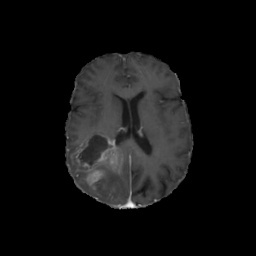      |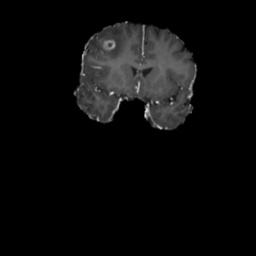        |      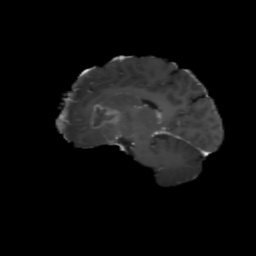       |


Note that this dataset has been already imported in this repository.

# Workspace Configuration

In [2]:
# Global imports
import shutil
import zipfile
import os
import torch
import urllib.request
from IPython.display import Image, display

In [3]:
# This block make sense only if runned on Google Collaboratory
if os.path.exists('sample_data'):
  shutil.rmtree('sample_data')

In [4]:
import shutil
import os
# Clone YOLOv5 Repository
if os.path.exists('yolov5/runs'):
  shutil.rmtree('yolov5/runs')
else:
  !git clone https://github.com/ultralytics/yolov5 
  %cd yolov5
  %pip install -r requirements.txt
  %cd ..

fatal: destination path 'yolov5' already exists and is not an empty directory.
/Users/rraviku2/develop/train_models/BrainTumorDetection/yolov5

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
/Users/rraviku2/develop/train_models/BrainTumorDetection


In [5]:
# Download and unzip the dataset

if not os.path.isfile('data.zip'):
  urllib.request.urlretrieve("https://github.com/giuseppebrb/BrainTumorDetection/blob/main/data.zip?raw=true", "data.zip")

with zipfile.ZipFile("data.zip","r") as zip_ref:
    zip_ref.extractall(".")

os.remove('data.zip')

In [6]:
# Folder for fine-tuned models
output_folder = 'output_models'
if os.path.exists(output_folder):
  shutil.rmtree(output_folder)
else :
  os.makedirs(output_folder)

In [7]:
#  Check if cuda available / mps available / only CPU
if torch.cuda.is_available():
  device = 0
else:
  device = 'cpu'

# Training

## Axial Plane Model

In [22]:
# Training axial plane
!python yolov5/train.py --img 480 --batch 64 --epochs 400 --data ./data/axial/axial.yaml --weights yolov5m.pt --device {device} --name axial --hyp ./data/augmentation.yaml

import os
import shutil

src = 'yolov5/runs/train/axial/weights/best.pt'
dst = f'{output_folder}/tumor_detector_axial.pt'

if os.path.exists(src):
    shutil.copyfile(src, dst)
else:
    print(f"Source file not found: {src}. Please check if training completed successfully.")
    
# Copy the fine-tuned model inside the output folder
shutil.copyfile('yolov5/runs/train/axial/weights/best.pt', f'{output_folder}/tumor_detector_axial.pt')

1315.88s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


zsh:1: command not found: python


NameError: name 'output_folder' is not defined

### F1 Curve

In [ ]:
display(Image(filename='yolov5/runs/train/axial/F1_curve.png'))

FileNotFoundError: [Errno 2] No such file or directory: 'yolov5/runs/train/axial/F1_curve.png'

### PR Curve

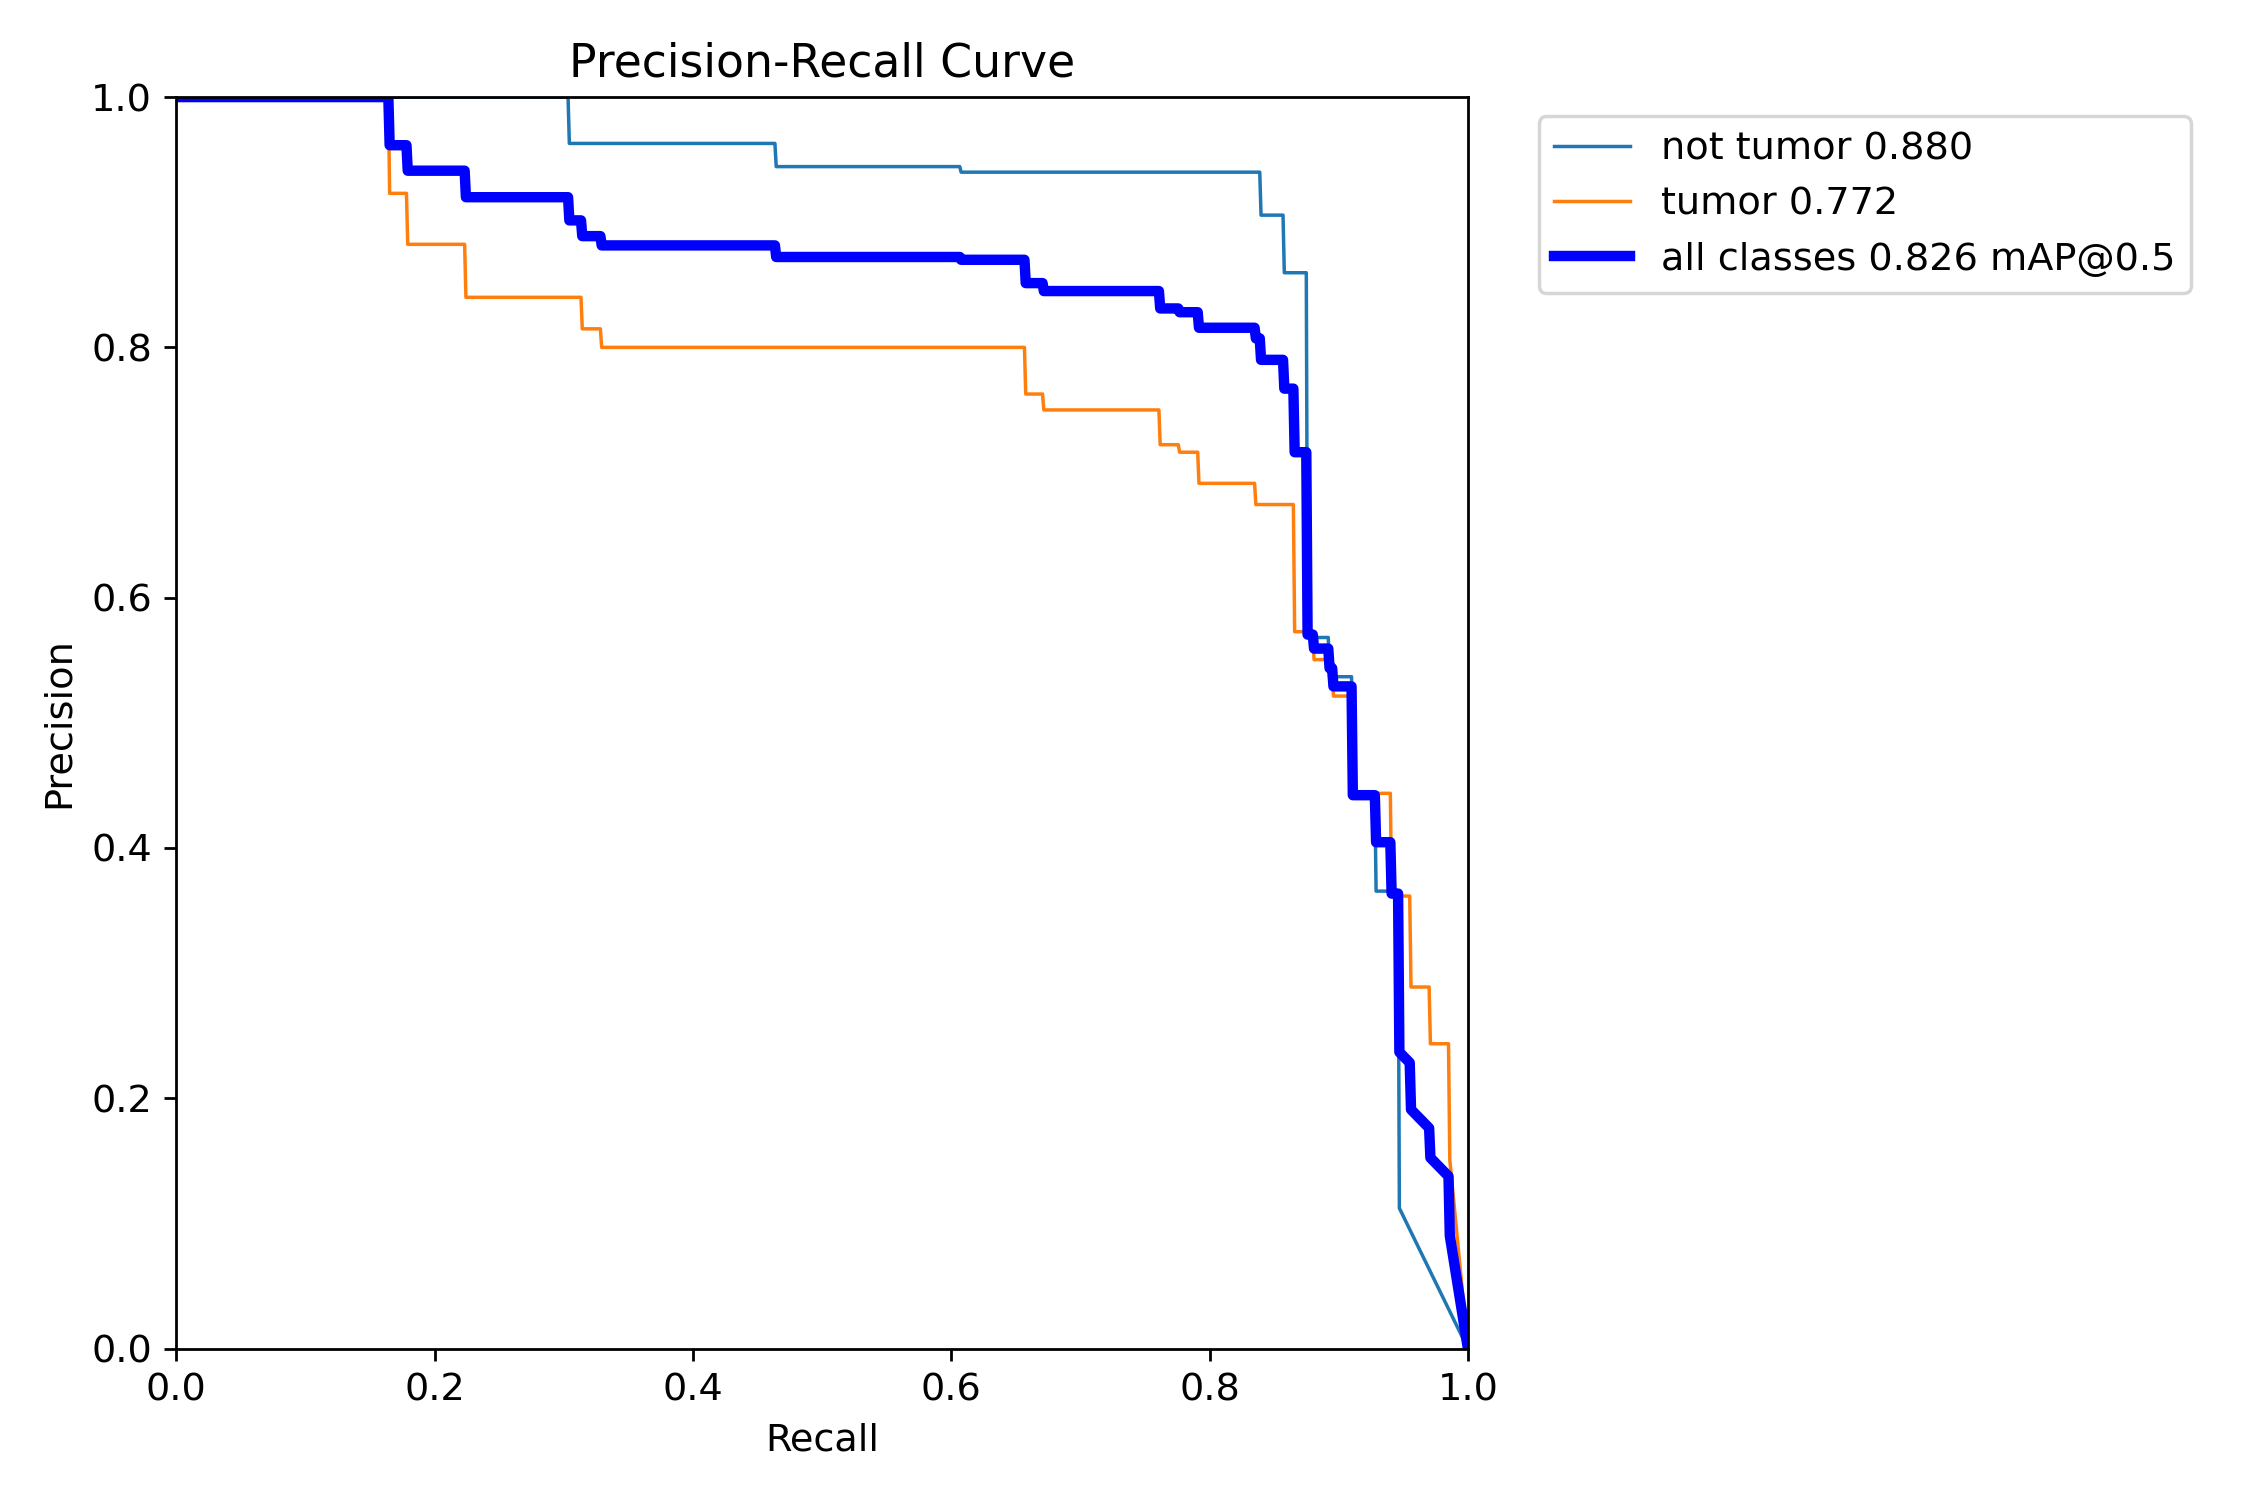

In [ ]:
display(Image(filename='yolov5/runs/train/axial/PR_curve.png'))

### Confusion Matrix

In [ ]:
display(Image(filename='yolov5/runs/train/axial/confusion_matrix.png'))

FileNotFoundError: [Errno 2] No such file or directory: 'yolov5/runs/train/axial/confusion_matrix.png'

### Results summary

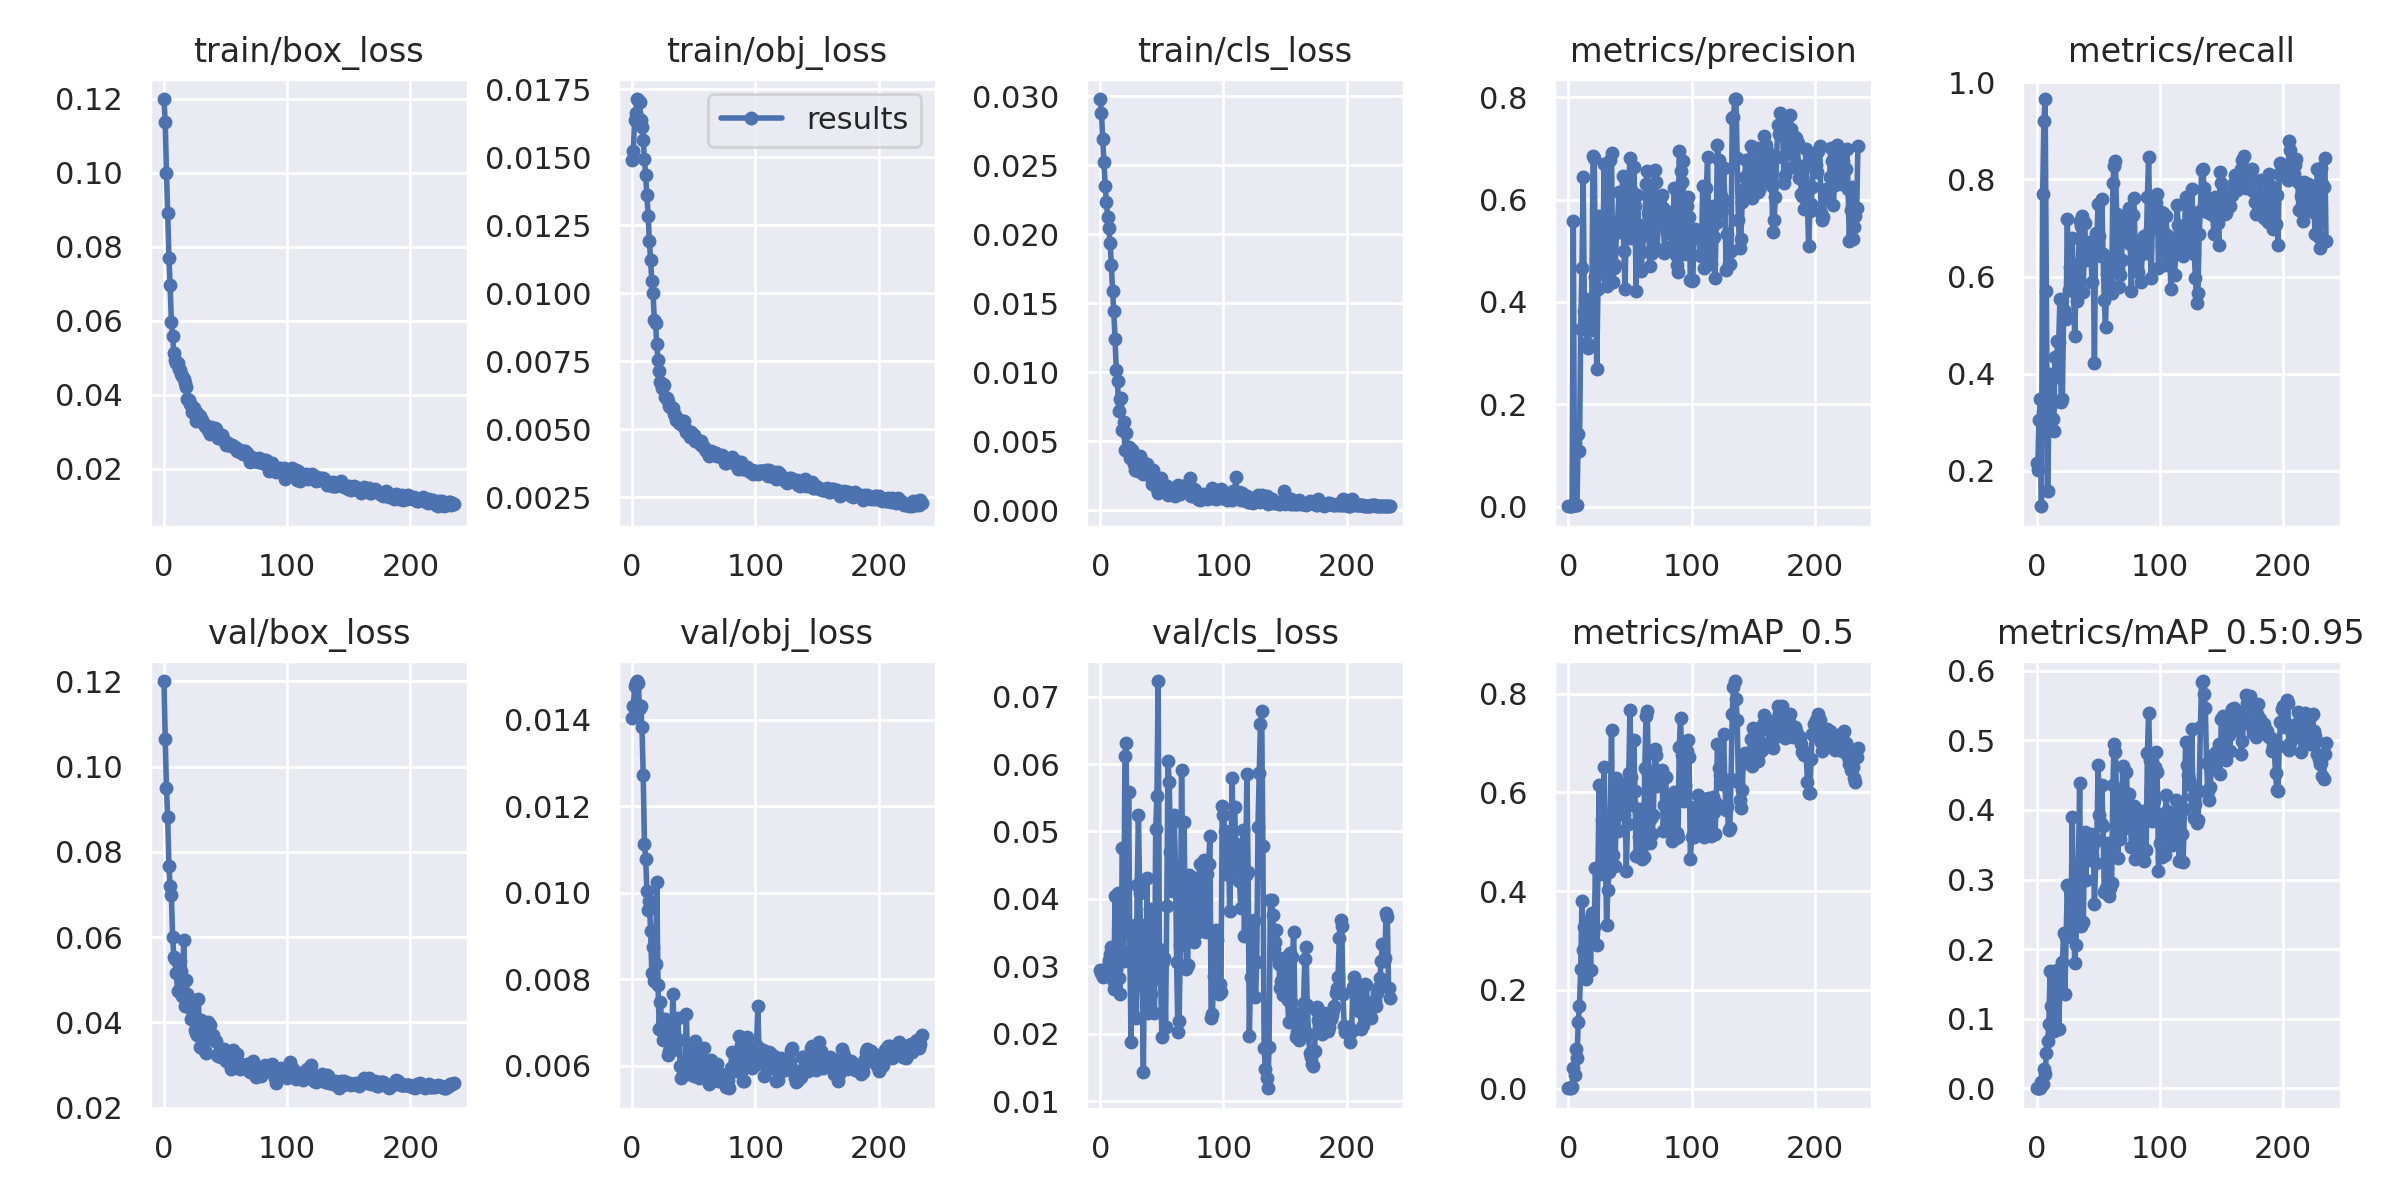

In [ ]:
display(Image(filename='yolov5/runs/train/axial/results.png'))

## Coronal Plane Model

In [12]:
# Training coronal plane
!python yolov5/train.py --img 480 --batch 80 --epochs 200 --data data/coronal/coronal.yaml --weights yolov5m.pt --device 0 --name coronal --hyp ./data/augmentation.yaml

# Copy the fine-tuned model inside the output folder
shutil.copyfile('yolov5/runs/train/coronal/weights/best.pt', f'{output_folder}/tumor_detector_coronal.pt')

train: weights=yolov5s.pt, cfg=, data=data/coronal/coronal.yaml, hyp=yolov5/data/hyps/hyp.scratch-low.yaml, epochs=200, batch_size=80, imgsz=640, rect=False, resume=False, nosave=False, noval=False, noautoanchor=False, noplots=False, evolve=None, bucket=, cache=None, image_weights=False, device=0, multi_scale=False, single_cls=False, optimizer=SGD, sync_bn=False, workers=8, project=yolov5/runs/train, name=coronal, exist_ok=False, quad=False, cos_lr=False, label_smoothing=0.0, patience=100, freeze=[0], save_period=-1, local_rank=-1, entity=None, upload_dataset=False, bbox_interval=-1, artifact_alias=latest
github: up to date with https://github.com/ultralytics/yolov5 ✅
YOLOv5 🚀 v6.1-261-g19f33cb Python-3.7.13 torch-1.11.0+cu113 CUDA:0 (Tesla T4, 15110MiB)

hyperparameters: lr0=0.01, lrf=0.01, momentum=0.937, weight_decay=0.0005, warmup_epochs=3.0, warmup_momentum=0.8, warmup_bias_lr=0.1, box=0.05, cls=0.5, cls_pw=1.0, obj=1.0, obj_pw=1.0, iou_t=0.2, anchor_t=4.0, fl_gamma=0.0, hsv_h=0.0

'output_models/tumor_detector_coronal.pt'

### F1 Curve

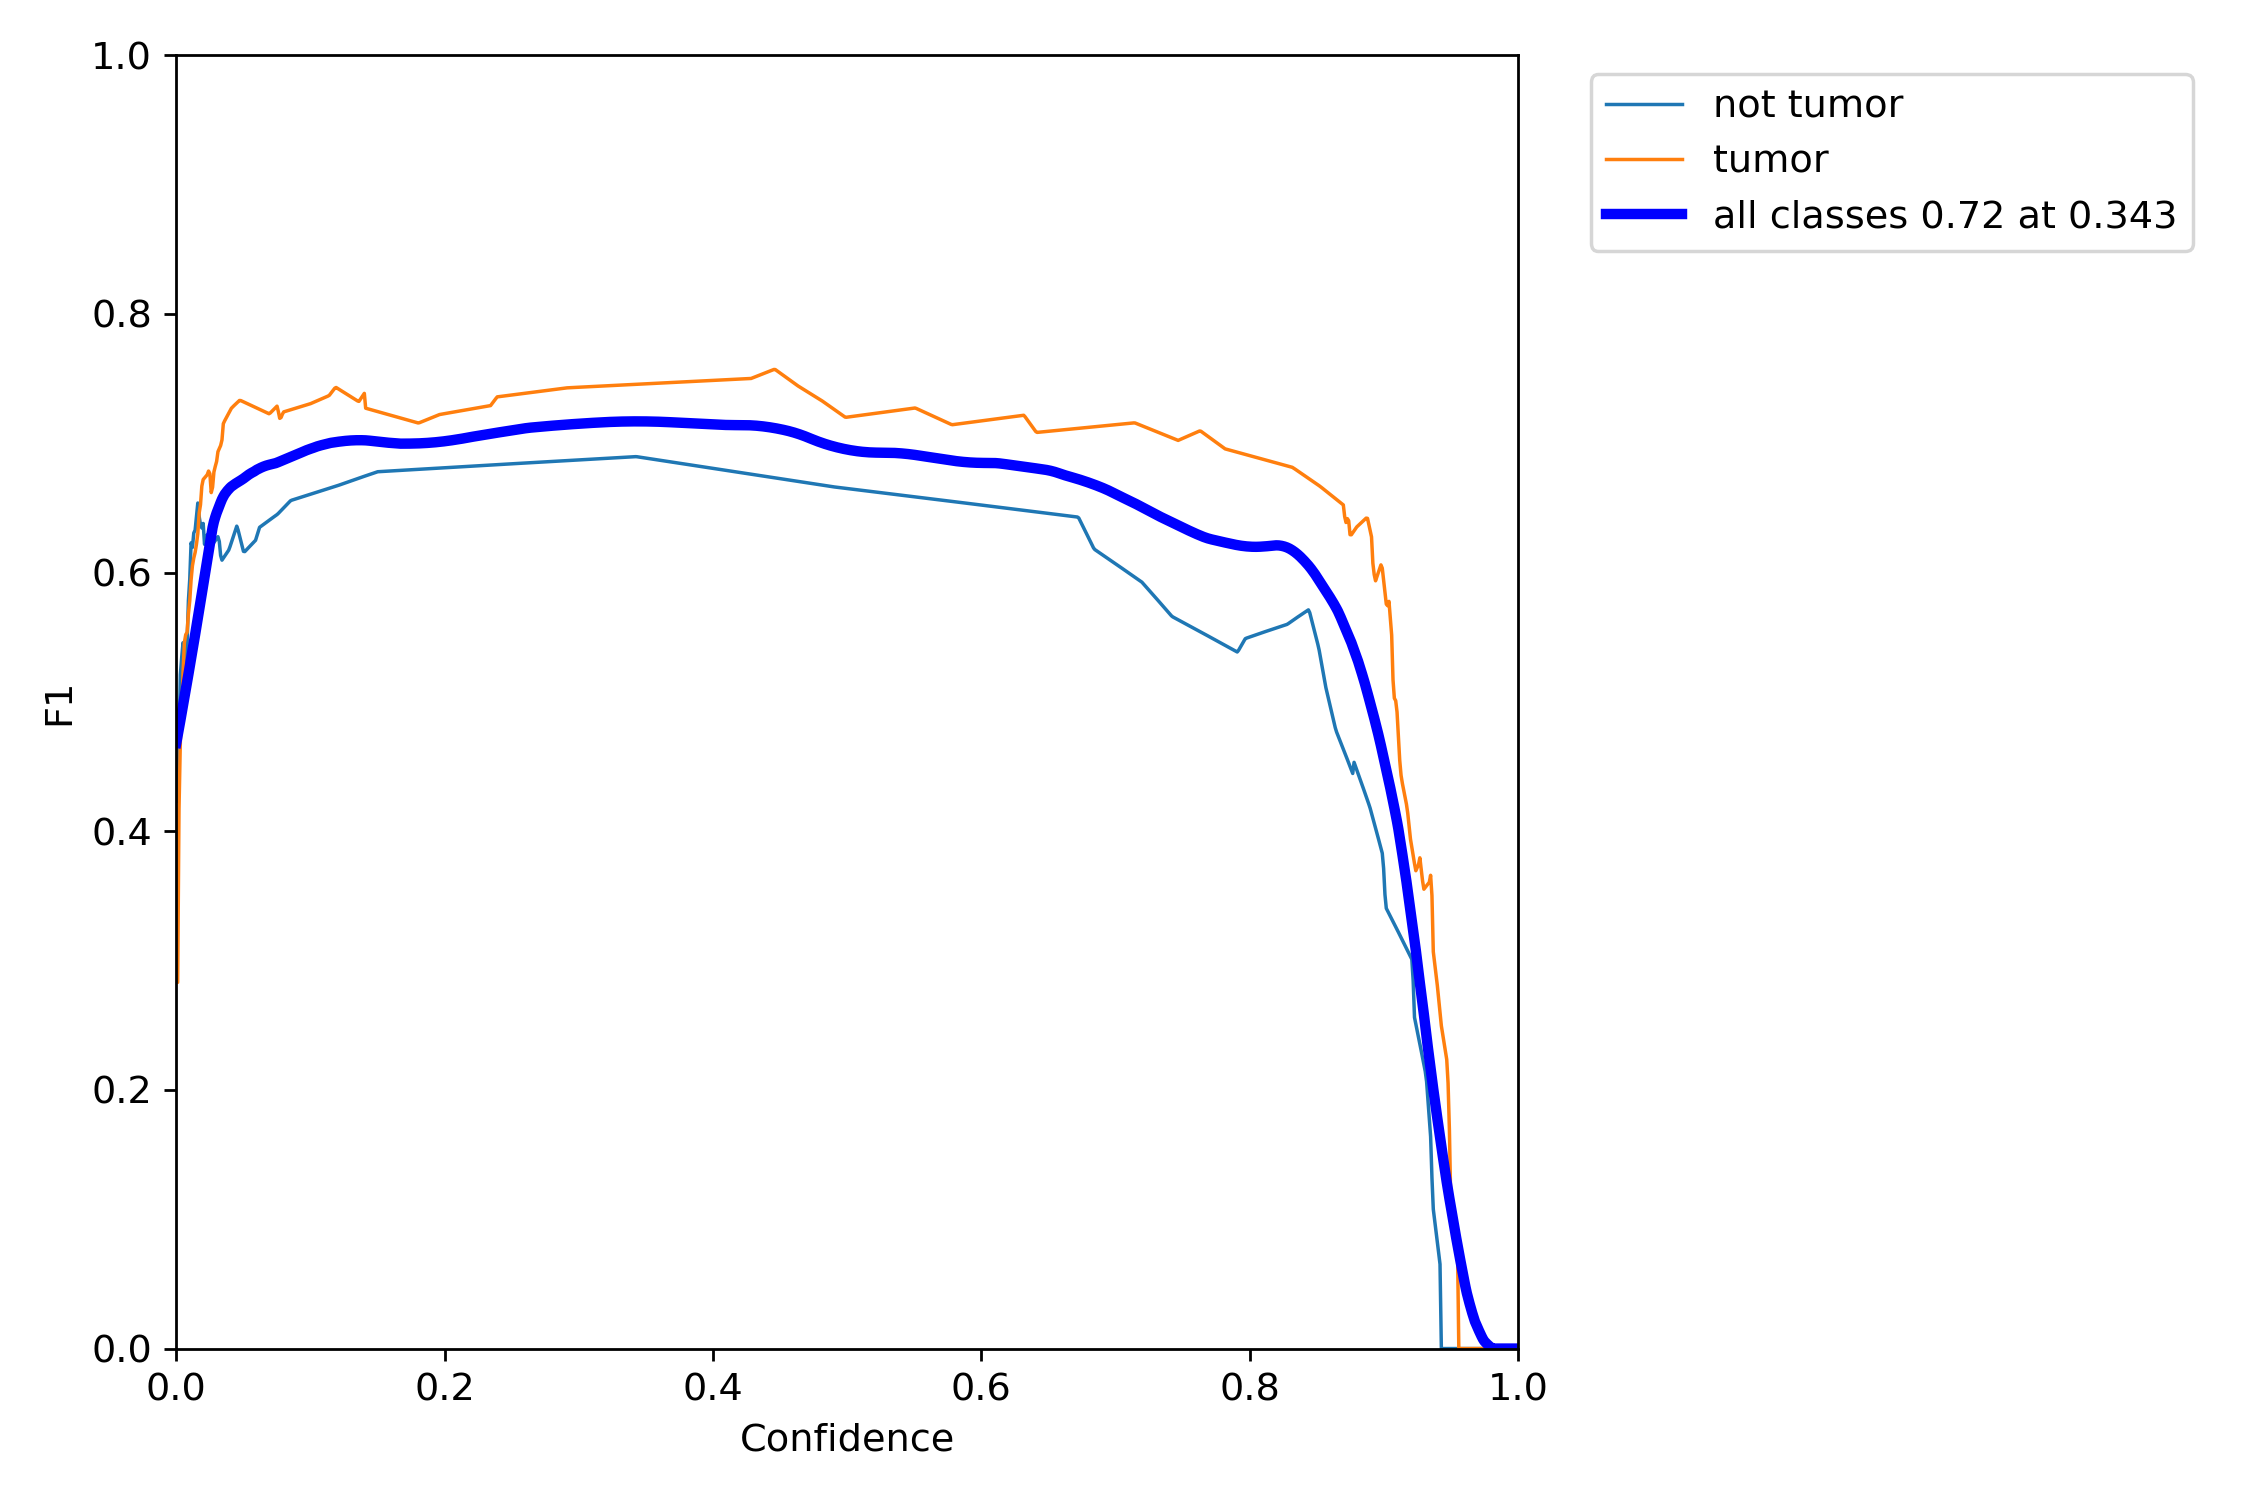

In [13]:
display(Image(filename='yolov5/runs/train/coronal/F1_curve.png'))

### PR Curve

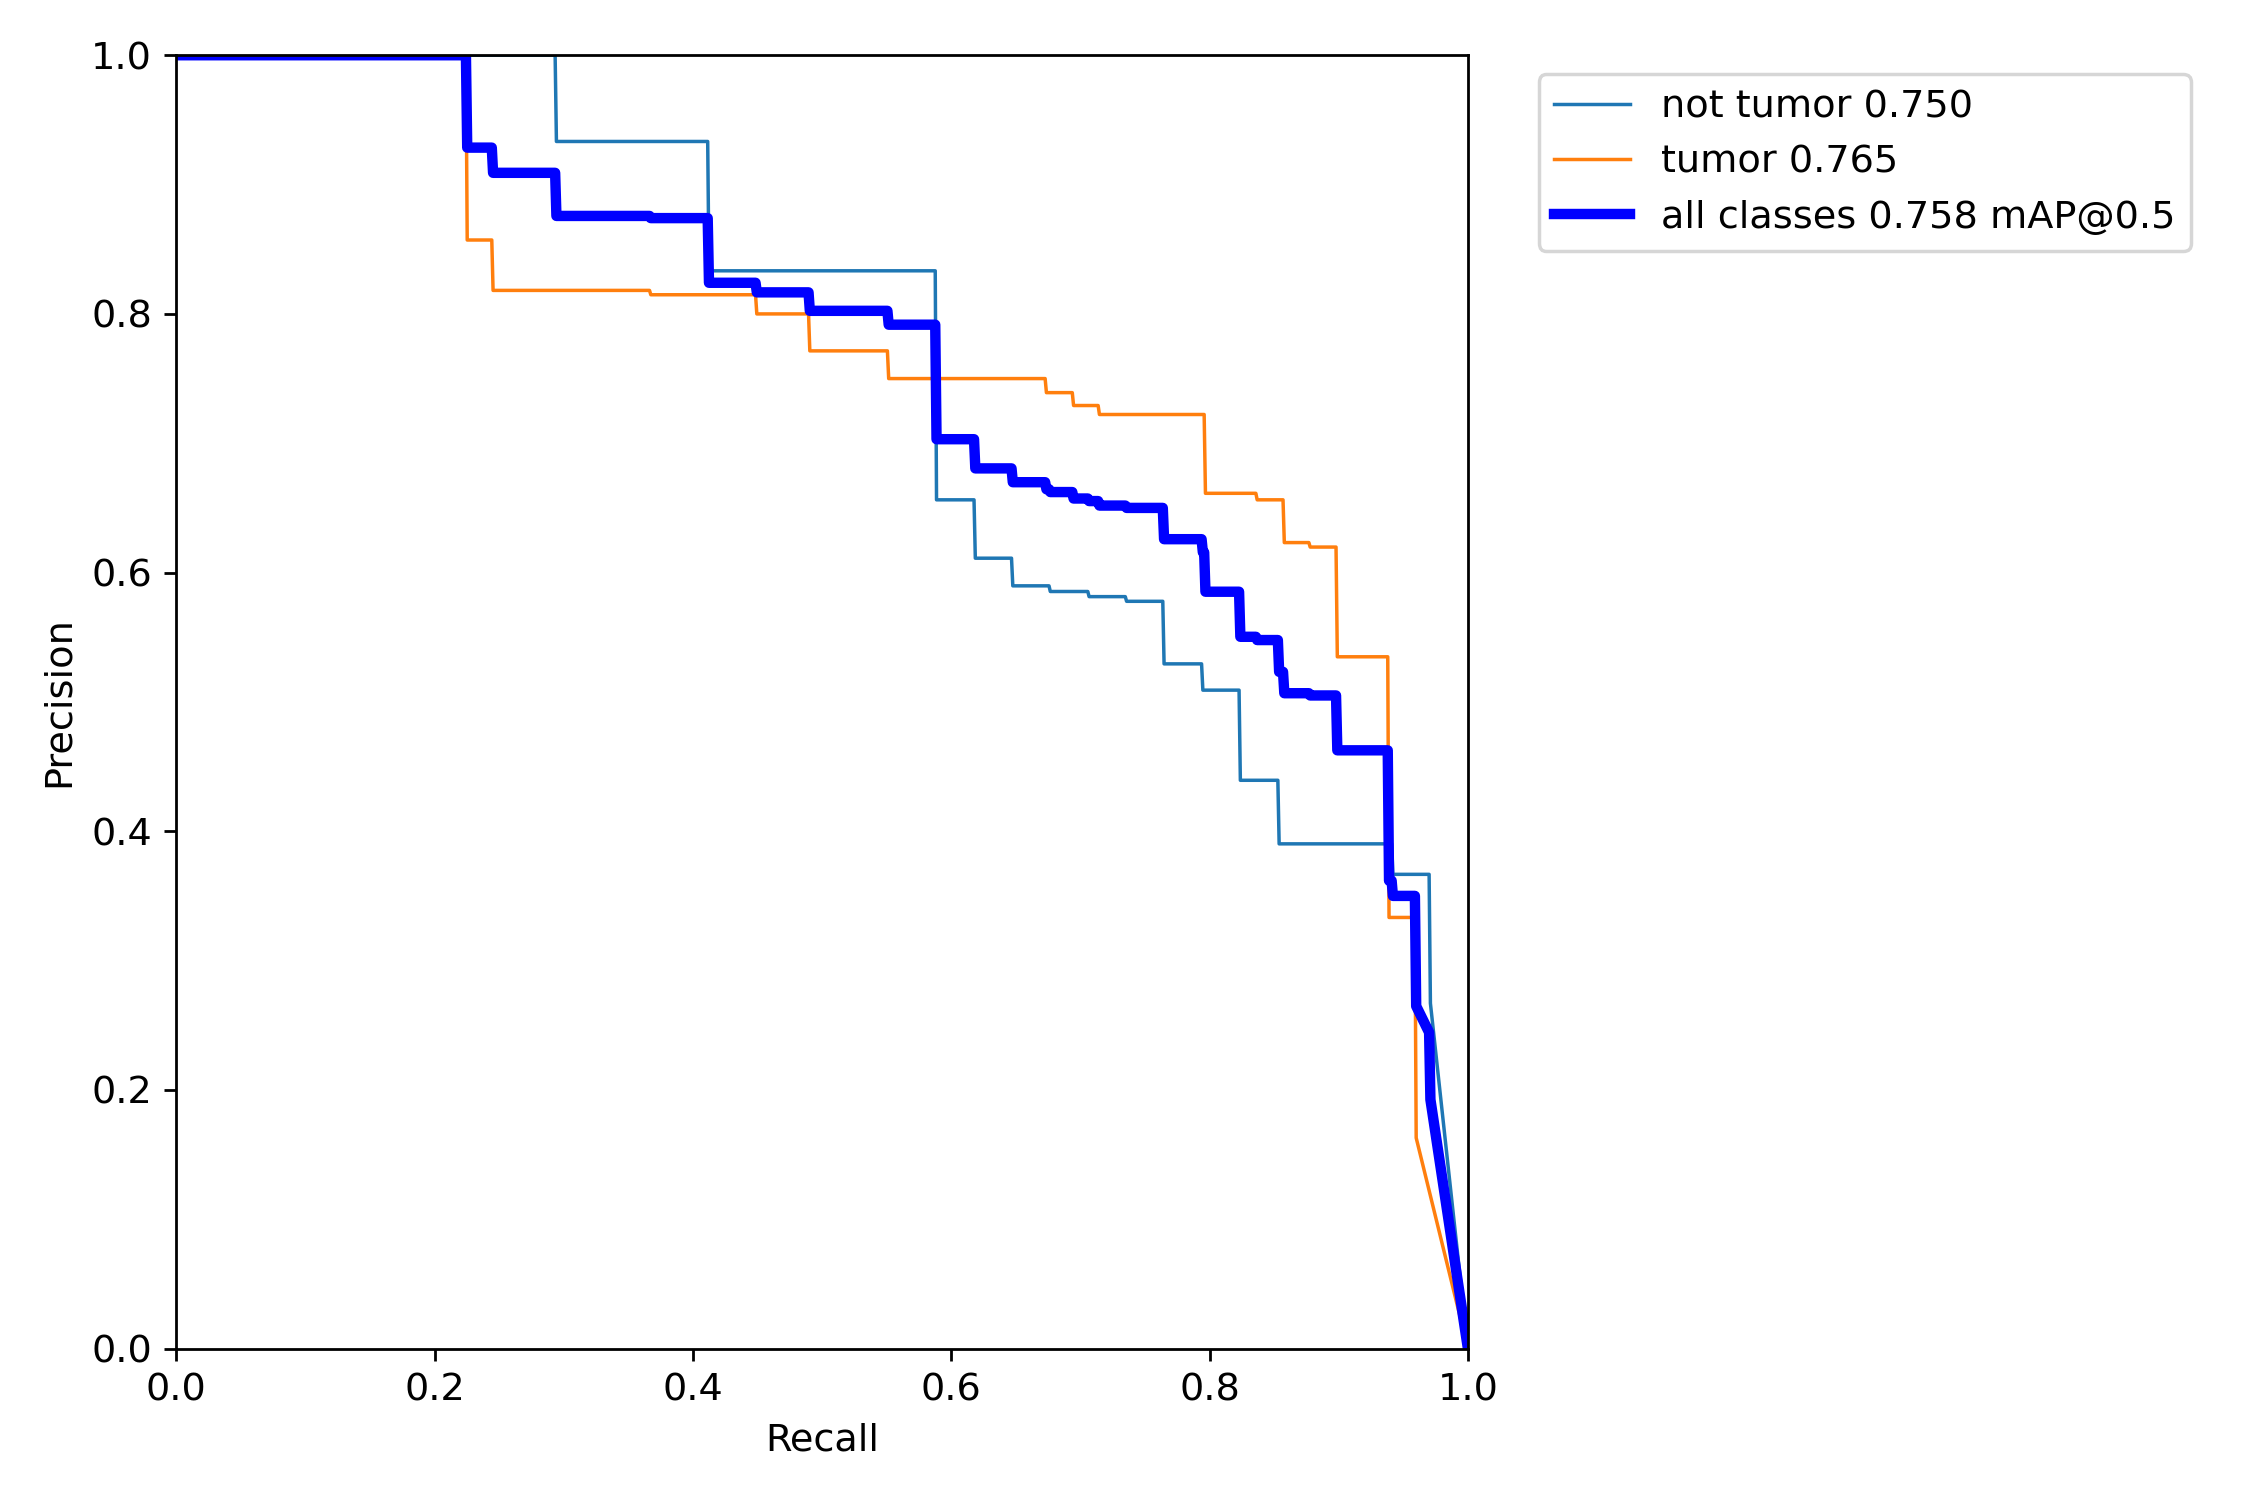

In [14]:
display(Image(filename='yolov5/runs/train/coronal/PR_curve.png'))

### Confusion Matrix

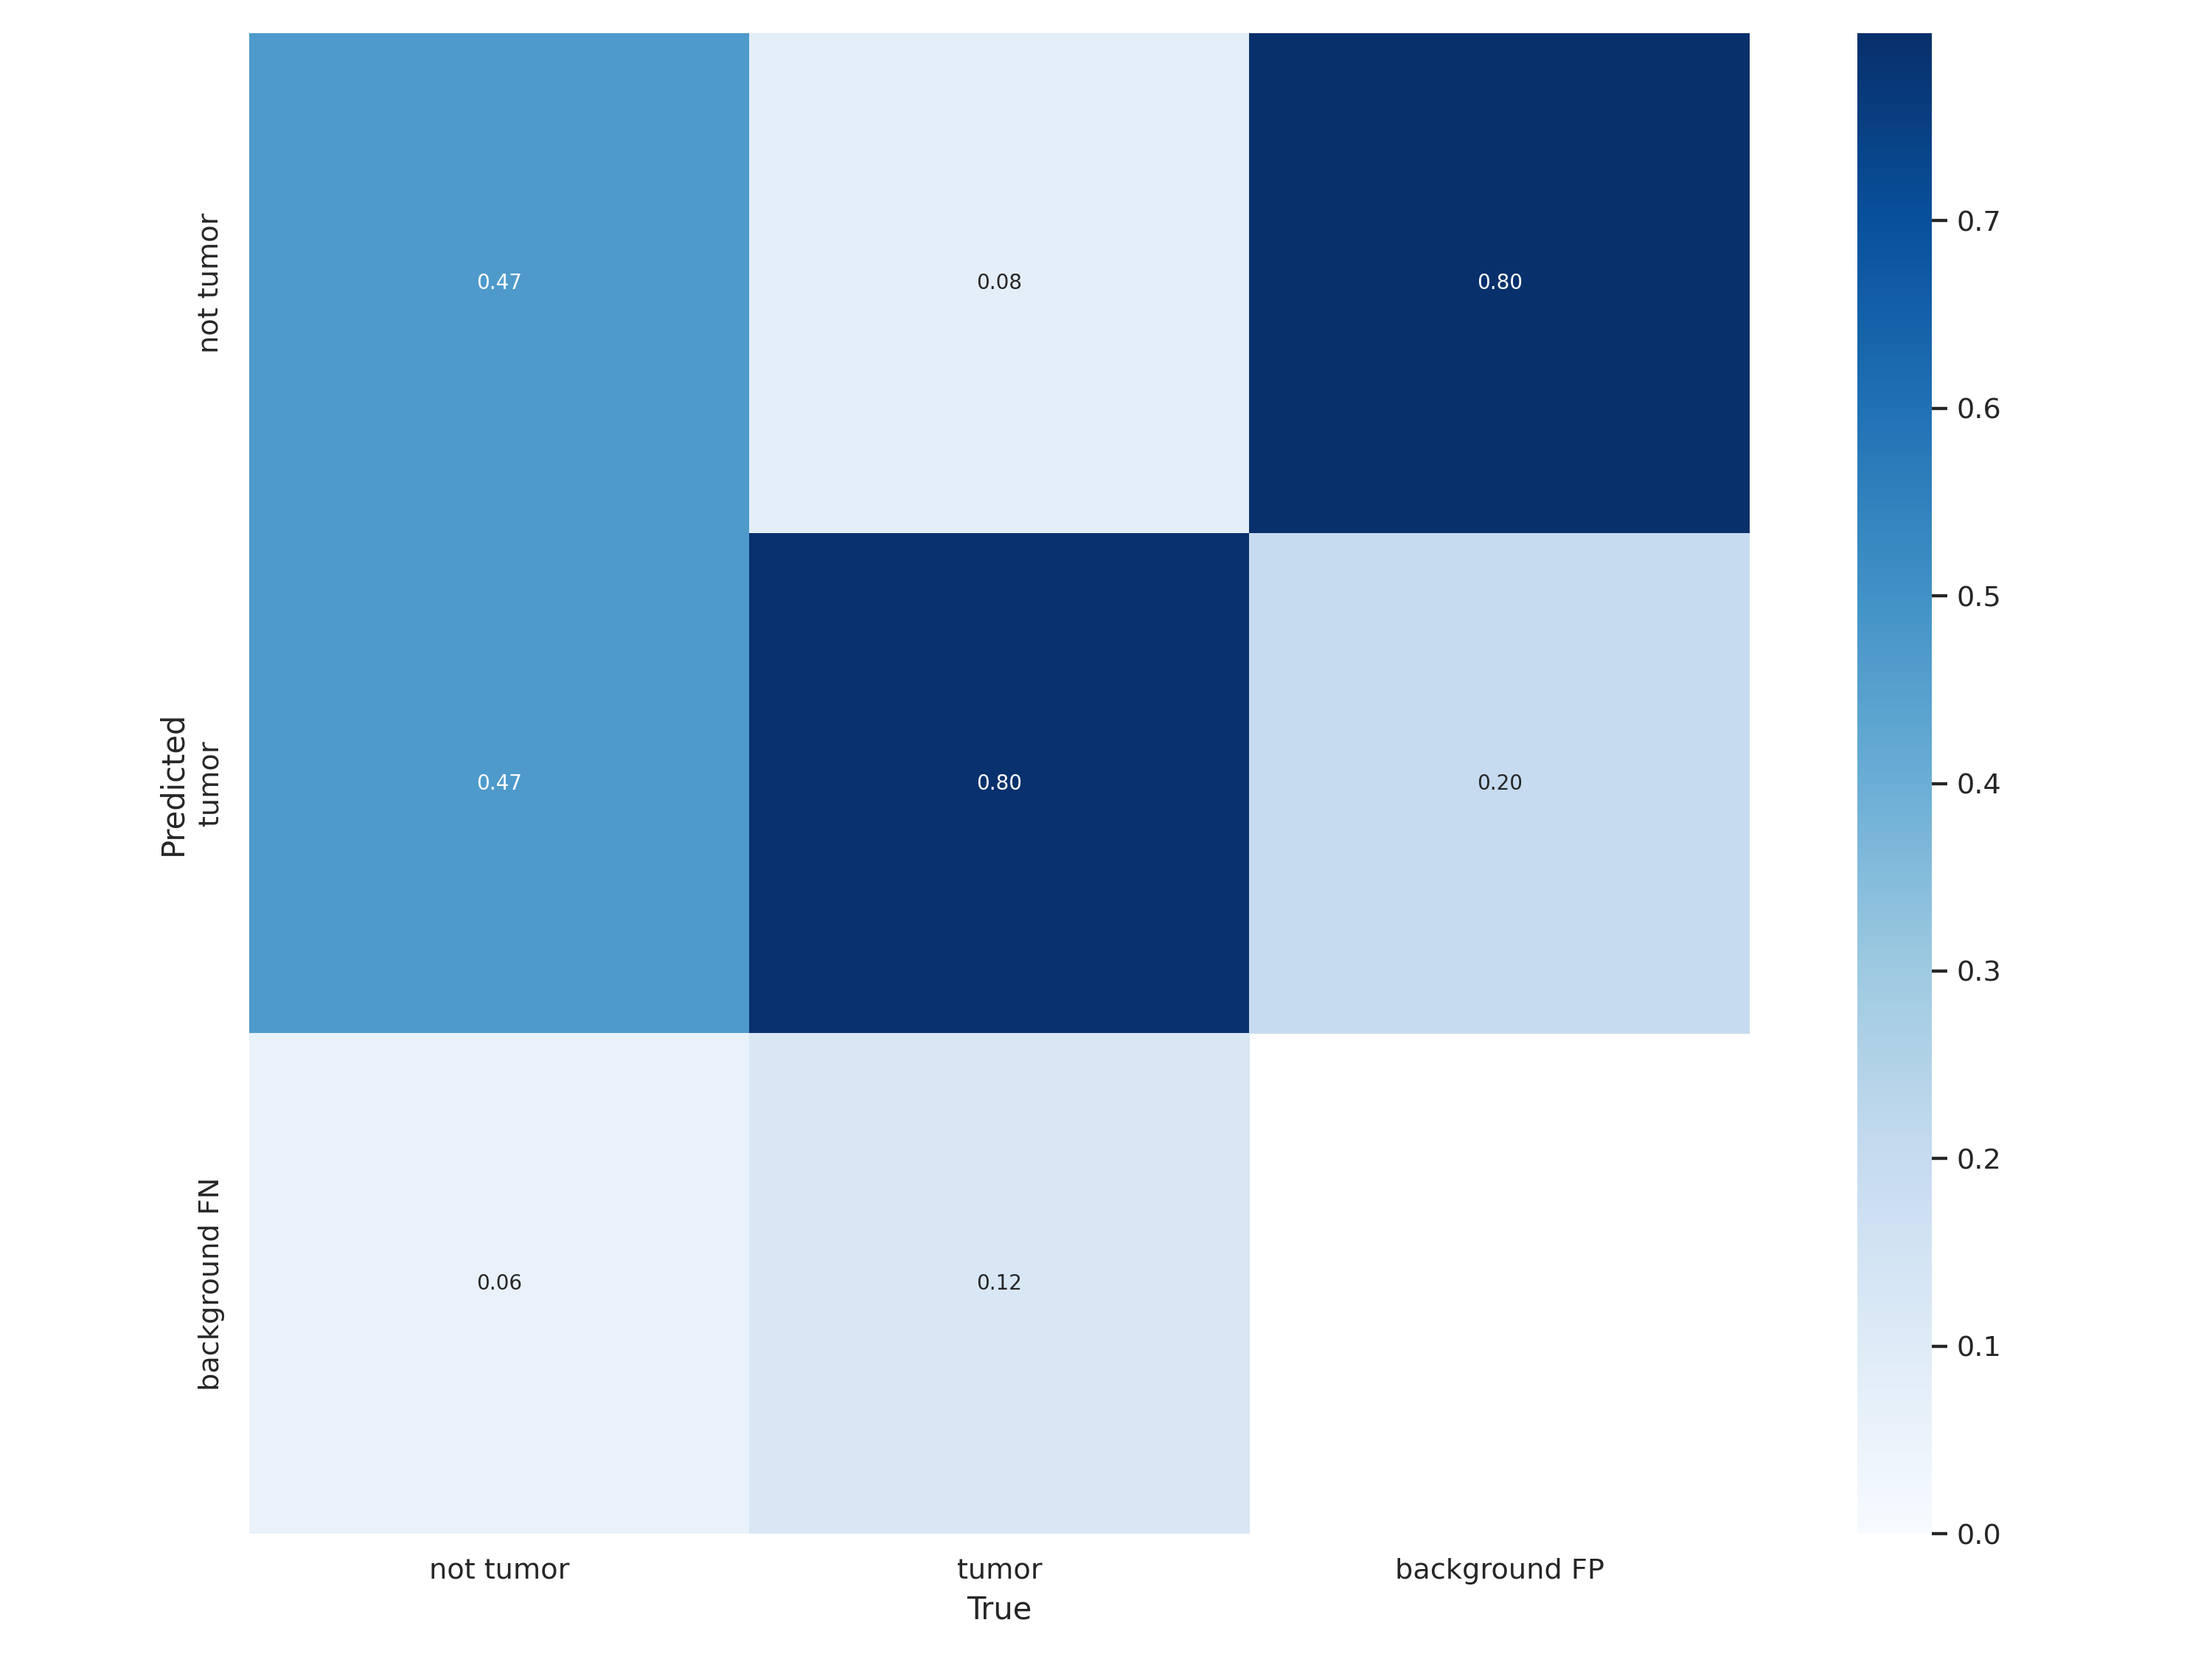

In [15]:
display(Image(filename='yolov5/runs/train/coronal/confusion_matrix.png'))

### Results Summary

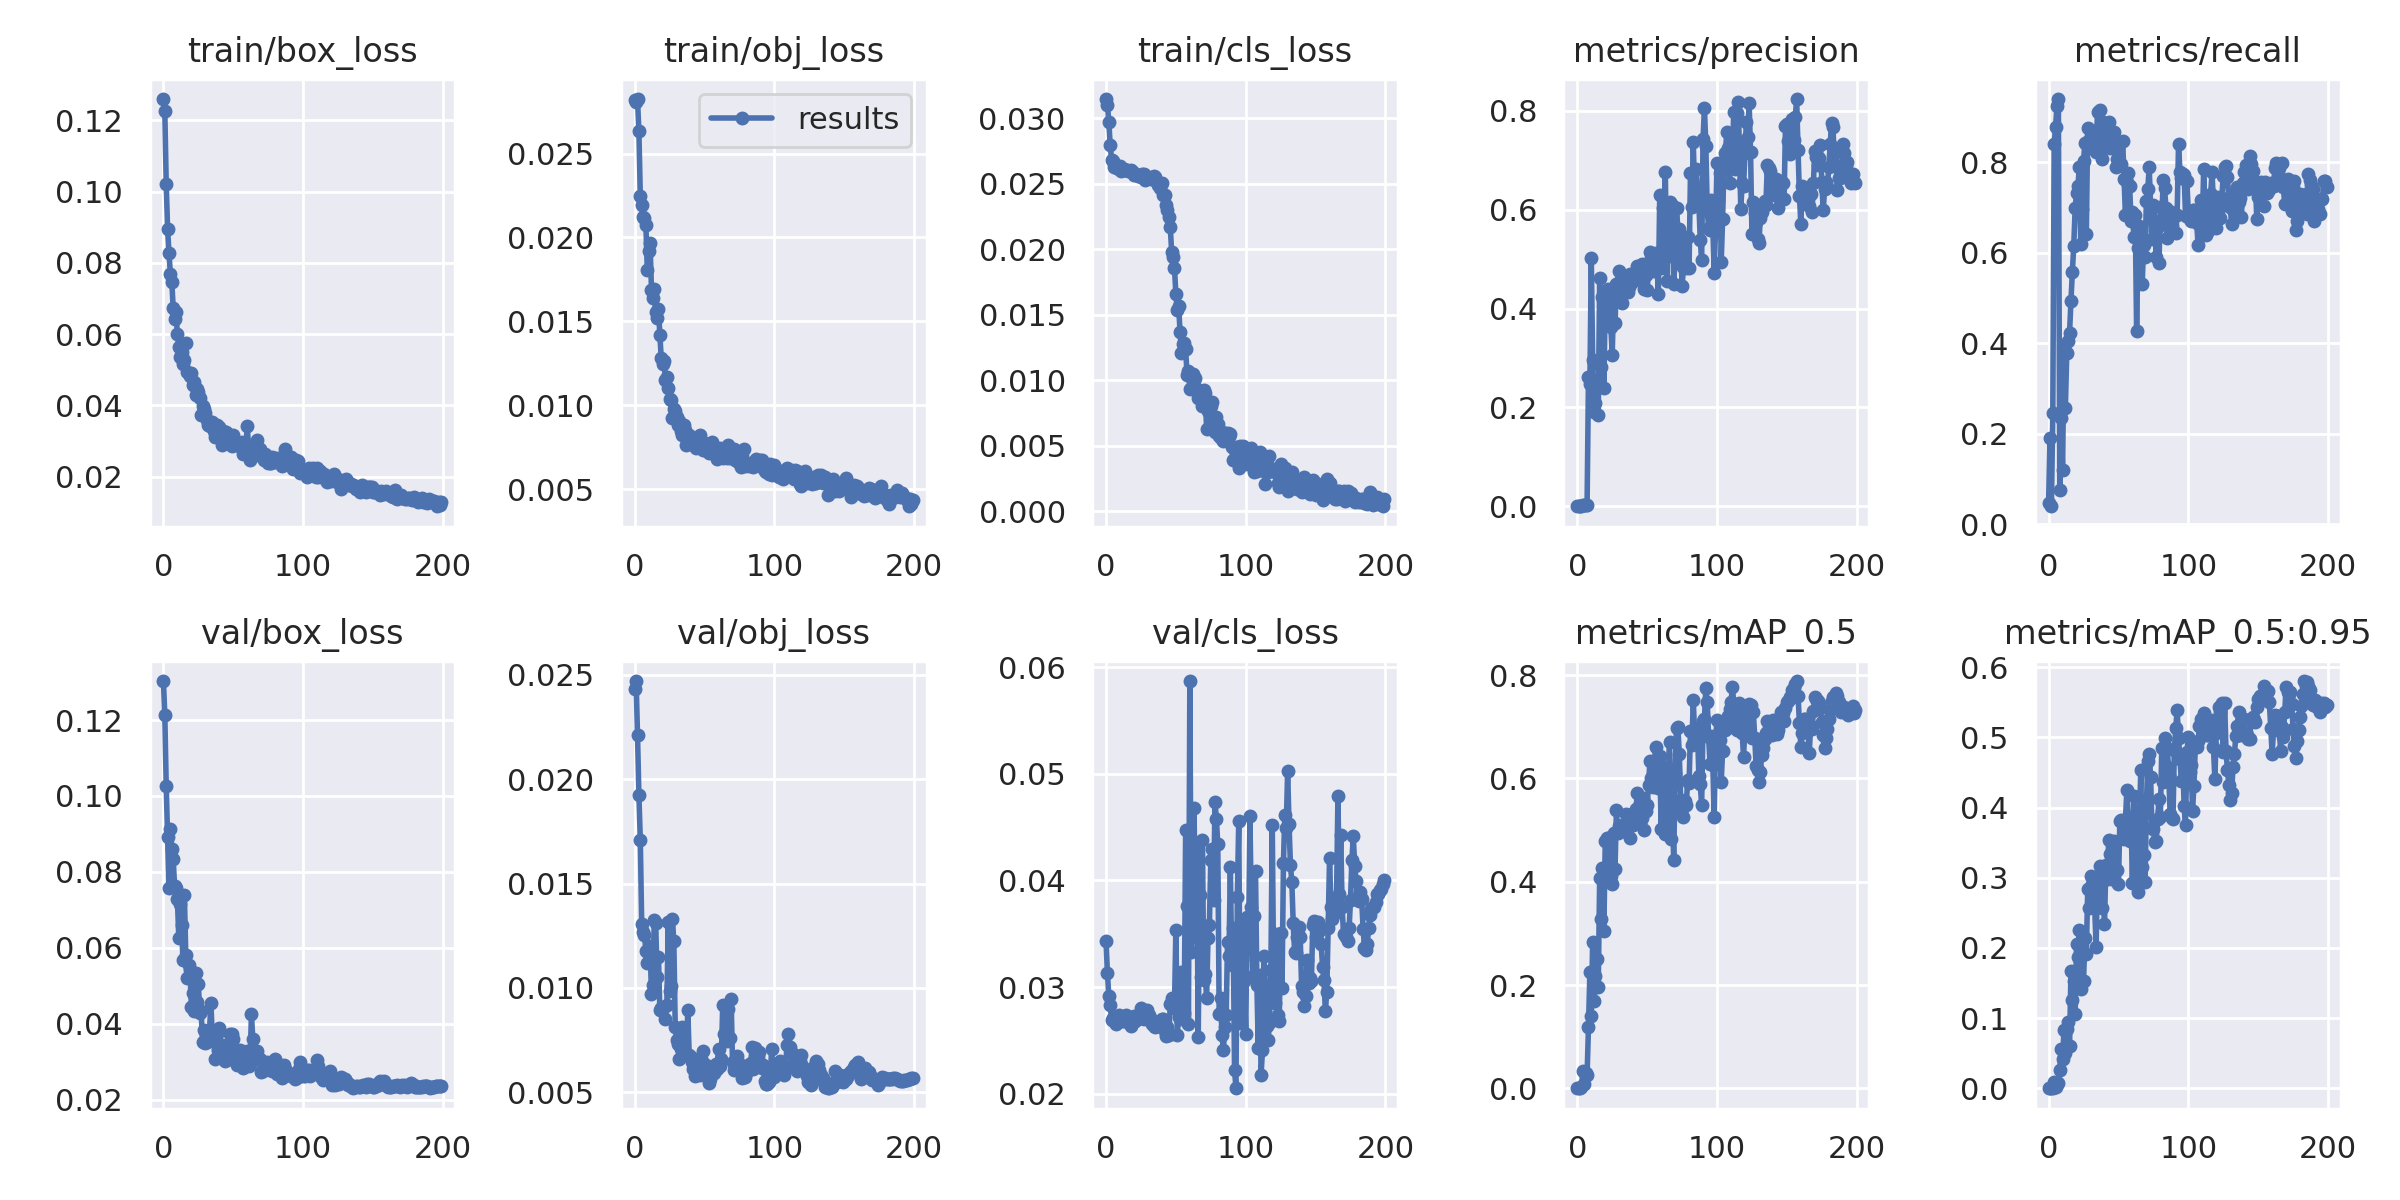

In [16]:
display(Image(filename='yolov5/runs/train/coronal/results.png'))

## Sagittal Plane Model

In [2]:
# Training sagittal plane
!python yolov5/train.py --img 480 --batch 80 --epochs 200 --data data/sagittal/sagittal.yaml --weights yolov5m.pt --device 0 --name sagittal --hyp ./data/augmentation.yaml

# Copy the fine-tuned model inside the output folder
shutil.copyfile('yolov5/runs/train/sagittal/weights/best.pt', f'{output_folder}/tumor_detector_sagittal.pt')

zsh:1: command not found: python


NameError: name 'shutil' is not defined

### F1 Curve

In [3]:
display(Image(filename='yolov5/runs/train/sagittal/F1_curve.png'))

FileNotFoundError: [Errno 2] No such file or directory: 'yolov5/runs/train/sagittal/F1_curve.png'

### PR Curve

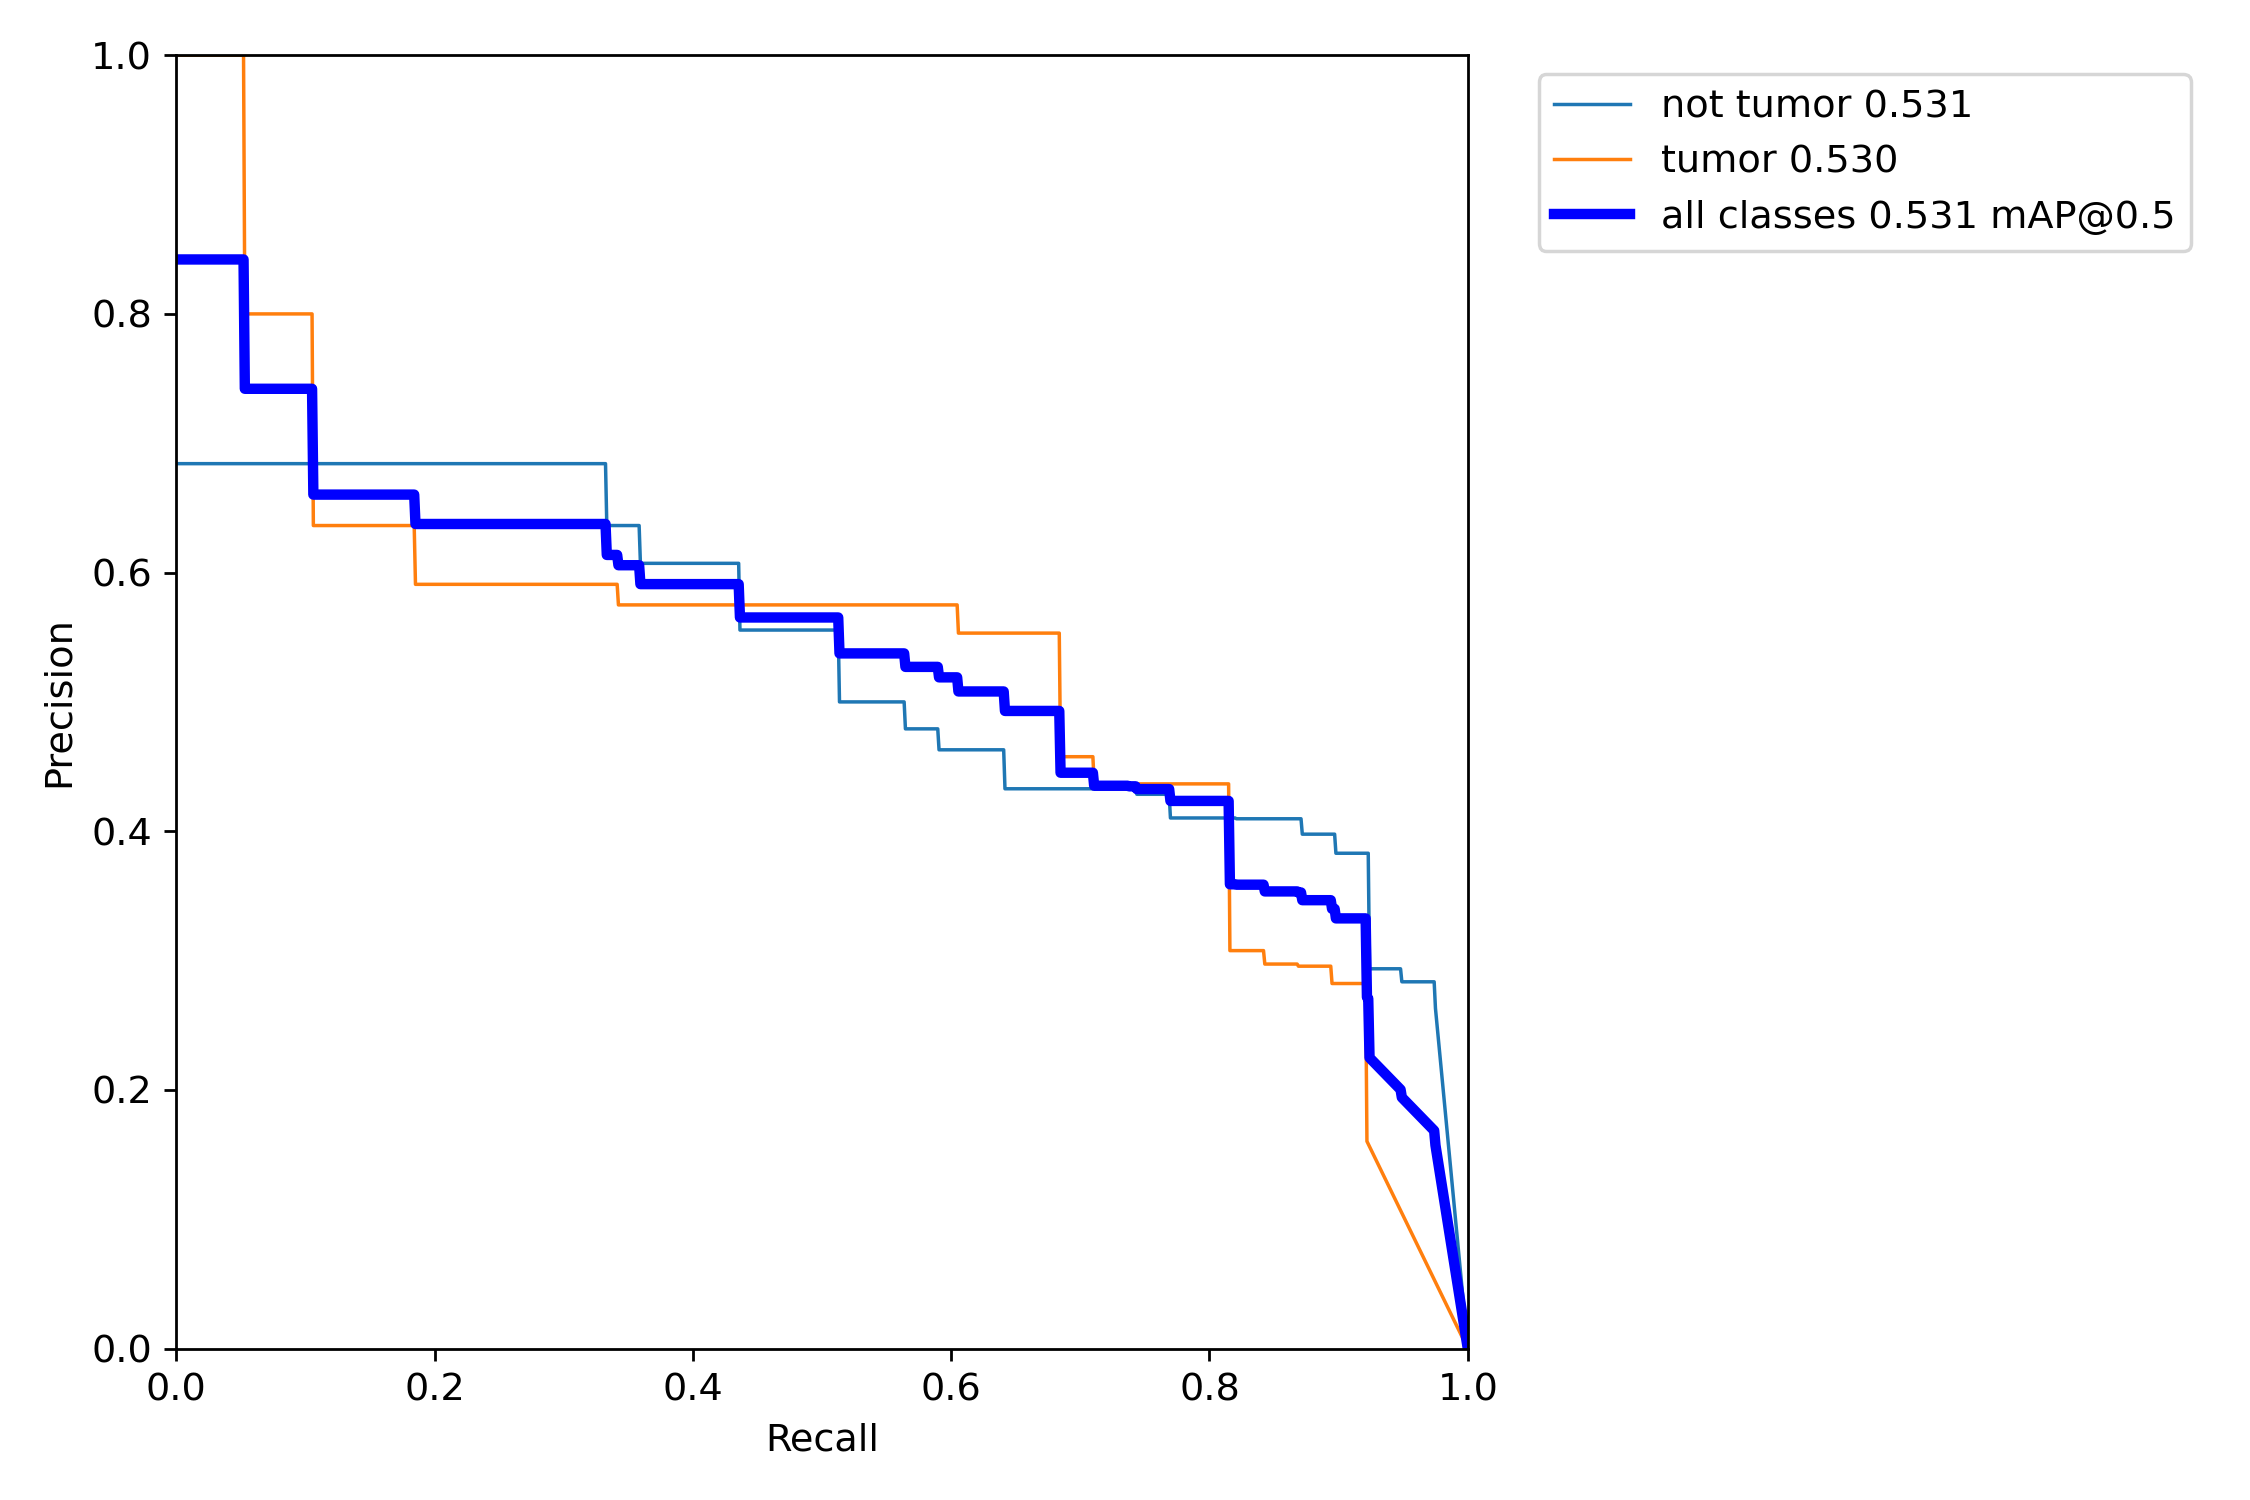

In [19]:
display(Image(filename='yolov5/runs/train/sagittal/PR_curve.png'))

### Confusion Matrix

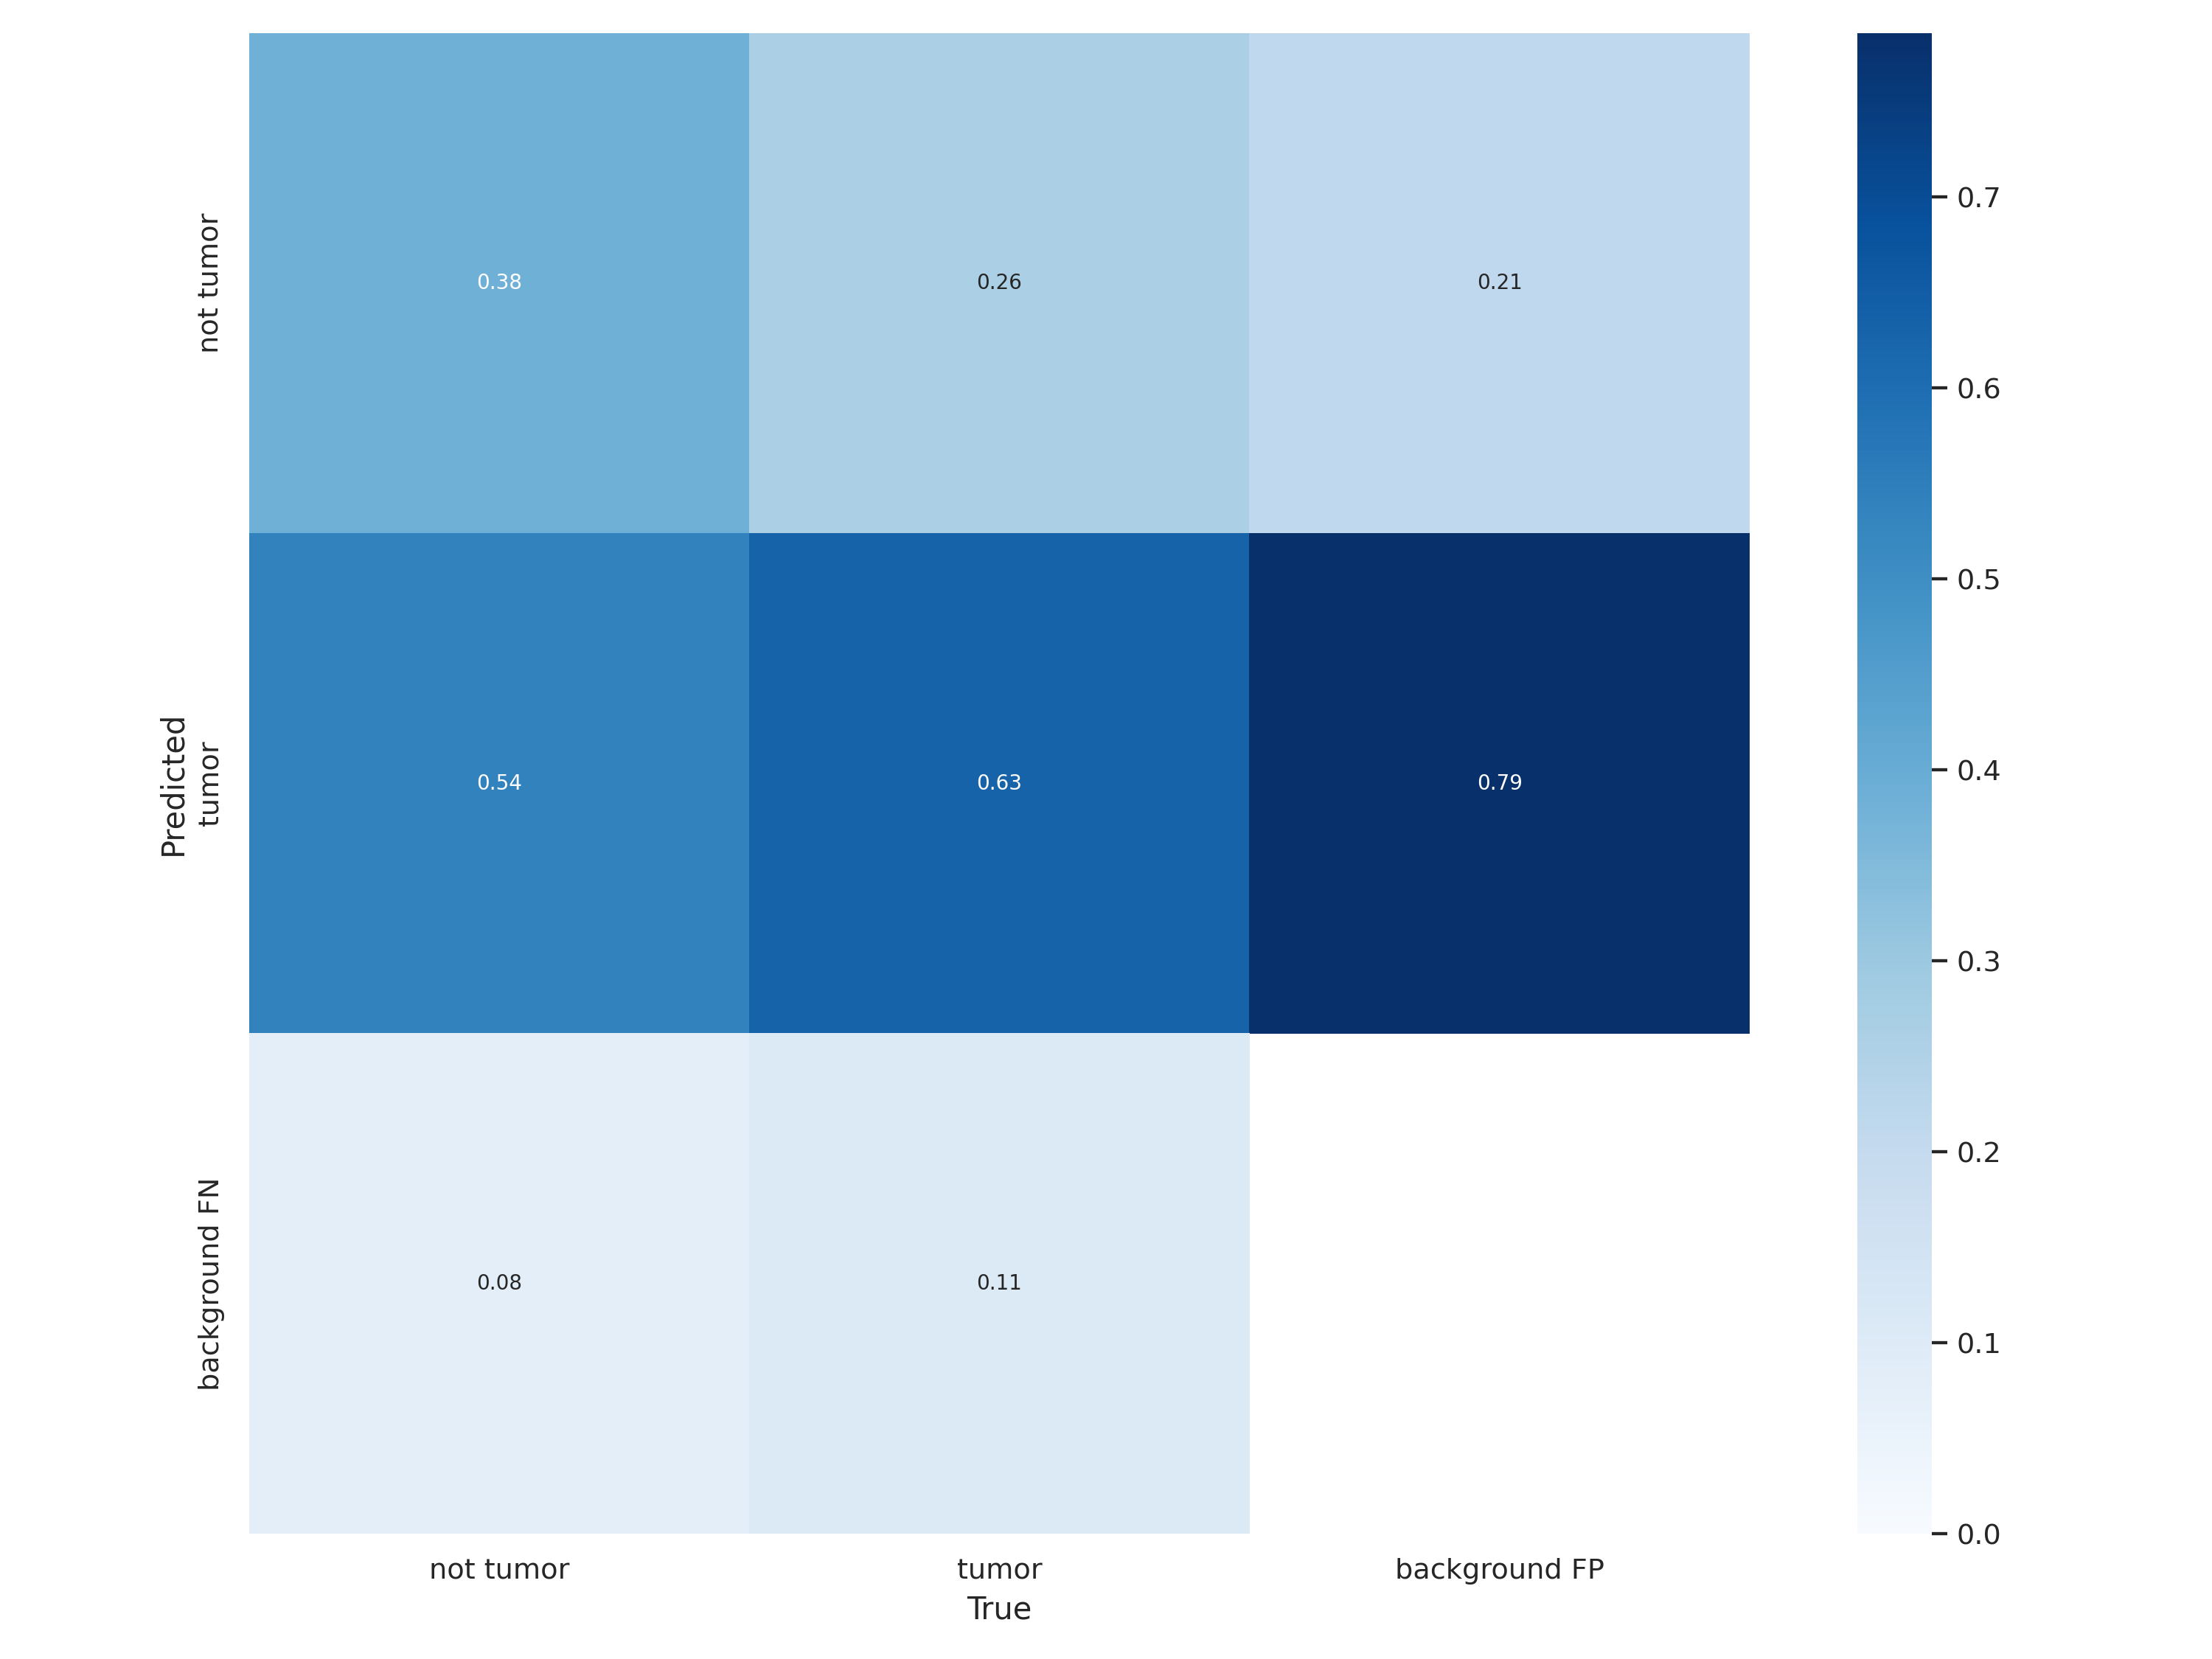

In [20]:
display(Image(filename='yolov5/runs/train/sagittal/confusion_matrix.png'))

### Results

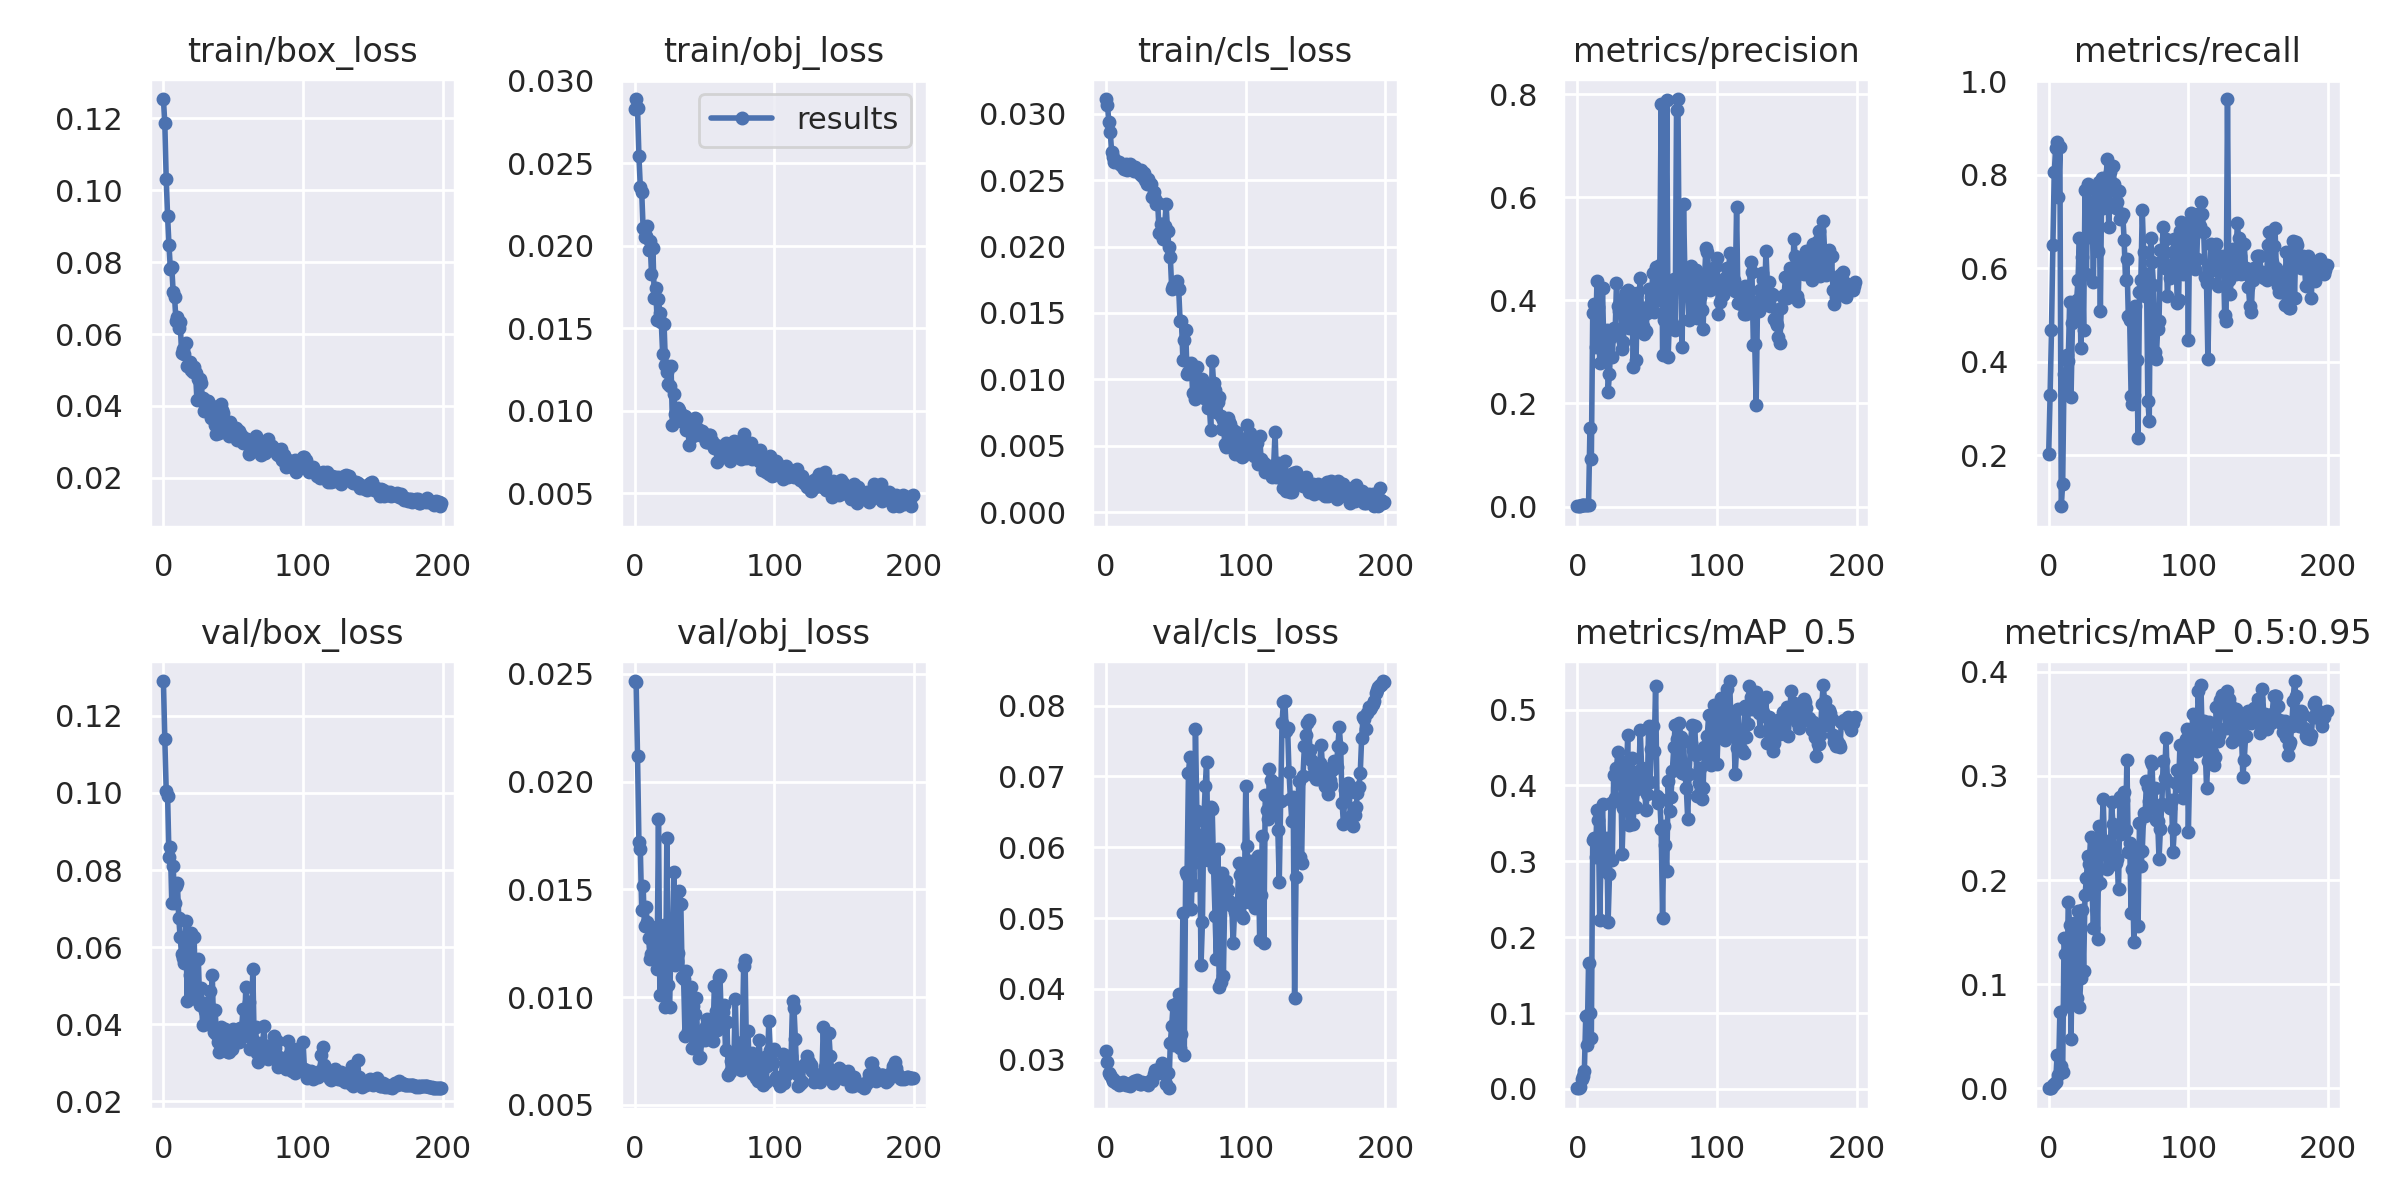

In [21]:
display(Image(filename='yolov5/runs/train/sagittal/results.png'))

# Testing the models

Let's test our models with never seen images during the training.

## Axial Model

1184.58s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


zsh:1: command not found: python


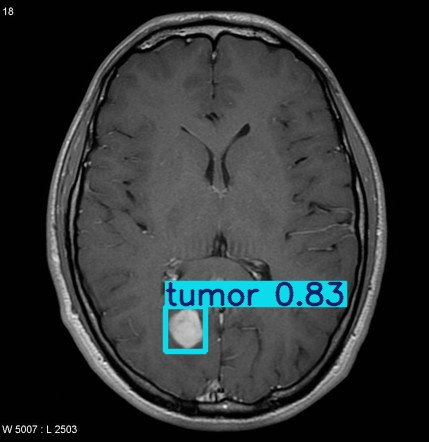

In [19]:
!python yolov5/detect.py --weights output_models/tumor_detector_axial.pt --img 640 --conf 0.4 --source https://prod-images-static.radiopaedia.org/images/5651/b510dc0d5cd3906018c4dd49b98643_gallery.jpeg --save-txt

from IPython.display import Image, display
display(Image(filename='yolov5/runs/detect/exp2/b510dc0d5cd3906018c4dd49b98643_gallery.jpeg'))

In [ ]:
from IPython.display import display, HTML
import glob
import os

# Original image URL
original_url = 'https://prod-images-static.radiopaedia.org/images/5651/b510dc0d5cd3906018c4dd49b98643_gallery.jpeg'

# Find the latest detected image
exp_folders = sorted(glob.glob('yolov5/runs/detect/exp*'), key=os.path.getmtime, reverse=True)
detected_img_path = ''
if exp_folders:
    candidate = os.path.join(exp_folders[0], 'b510dc0d5cd3906018c4dd49b98643_gallery.jpeg')
    if os.path.exists(candidate):
        detected_img_path = candidate

# Display side by side using HTML
if detected_img_path:
    html = f'''<div style="display: flex; gap: 20px; align-items: flex-start;">
        <div><b>Original Image</b><br><img src="{original_url}" width="320"></div>
        <div><b>Tumor Detected</b><br><img src="{detected_img_path}" width="320"></div>
    </div>'''
    display(HTML(html))
else:
    print("Detected image not found.")

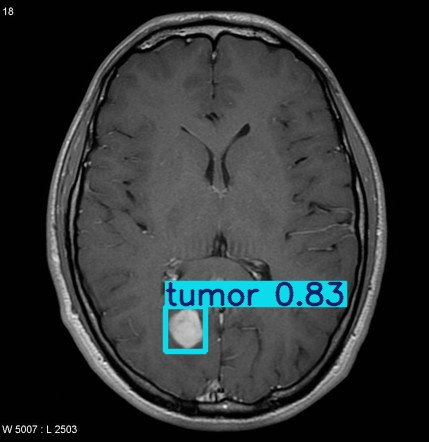

In [25]:
from IPython.display import Image, display

# Display the original image
original_url = 'https://prod-images-static.radiopaedia.org/images/5651/b510dc0d5cd3906018c4dd49b98643_gallery.jpeg'
display(Image(url=original_url))

# Display the tumor detected image (auto-detect latest exp folder)
import glob
import os

exp_folders = sorted(glob.glob('yolov5/runs/detect/exp2'), key=os.path.getmtime, reverse=True)
if exp_folders:
    img_path = os.path.join(exp_folders[0], 'b510dc0d5cd3906018c4dd49b98643_gallery.jpeg')
    if os.path.exists(img_path):
        display(Image(filename=img_path))
    else:
        print(f"Detected image not found: {img_path}")
else:
    print("No detection output folders found.")

## Coronal Model

1195.49s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


zsh:1: command not found: python


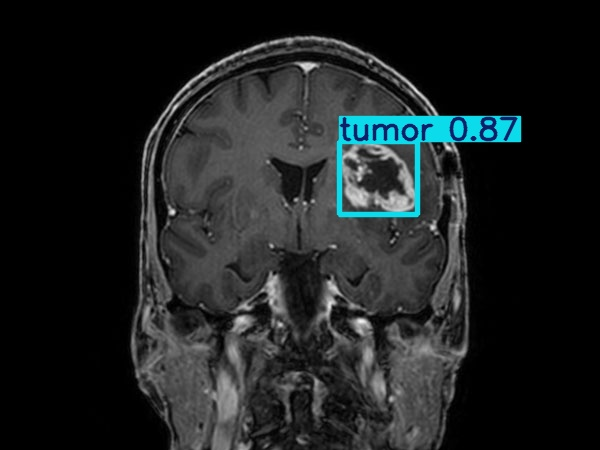

In [20]:
!python yolov5/detect.py --weights output_models/tumor_detector_coronal.pt --img 640 --conf 0.4 --source https://www.mriclinicalcasemap.philips.com/content/images/cases/case154/thumbs/14.jpg --save-txt

display(Image(filename='yolov5/runs/detect/exp3/14.jpg'))

## Sagittal Model

1253.62s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


zsh:1: command not found: python


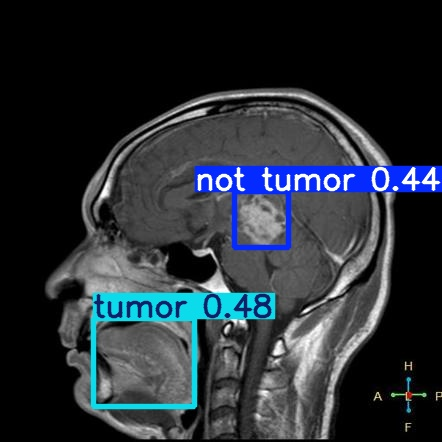

In [21]:
!python yolov5/detect.py --weights output_models/tumor_detector_sagittal.pt --img 640 --conf 0.4 --source https://prod-images-static.radiopaedia.org/images/4440984/10a4749375e20983b677e0502a9d7f_gallery.jpg --save-txt

display(Image(filename='yolov5/runs/detect/exp4/10a4749375e20983b677e0502a9d7f_gallery.jpg'))